## Shorten Up or Swing Away? An ML Approach to Two-Strike Hitting
The following code utilizes Statcast bat-tracking data from the 2024 and 2025 MLB seasons, analyzing whether shortening up in two-strike counts is in fact an effective approach at the plate.

- Data Source: https://www.kaggle.com/code/yasunorim/mlb-bat-tracking-analysis-2024-2025

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pybaseball import playerid_reverse_lookup

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

from scipy import stats
from scipy.stats import levene, shapiro, kruskal

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

### 1. Data Load + Cleaning

In [244]:
# 2024 + 2025 Pitch Level Data
df = pd.read_csv('statcast_bat_tracking_2024_2025.csv')

In [245]:
print(df.shape)
df.head()

(1443801, 118)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2024-09-29,94.8,-1.08,6.25,"Nelson, Ryne",444482,669194,field_out,hit_into_play,NaN,NaN,NaN,NaN,14.0,"David Peralta grounds out, first baseman Chris...",R,L,R,AZ,SD,X,3.0,ground_ball,0,0,2024,-0.33,1.61,0.16,1.50,NaN,NaN,NaN,2,9,Top,156.22,161.23,NaN,NaN,NaN,NaN,4.029891,-137.743734,-10.441149,-5.060805,30.602608,-9.493986,3.57,1.70,5.0,98.1,-17.0,95.7,2151.0,6.9,747147,672515,572233,621028,553993,672695,664983,677950,682998,53.59,0.182,0.192,0.0,1.0,0.0,0.0,2.0,74,1,4-Seam Fastball,11,2,2,11,2,11,2,11,Strategic,Standard,194.0,0.001,-0.256,80.7,7.6,0.186,0.256,98.1,9,-9,0.999,0.001,26,36,26,37,1,3,21.0,1.0,NaN,6.0,0.93,0.33,-0.33,57.3,2.947666,-7.564949,39.889697,33.931754,26.691518
1,FC,2024-09-29,90.1,-1.59,6.04,"Nelson, Ryne",630105,669194,field_out,hit_into_play,NaN,NaN,NaN,NaN,7.0,Jake Cronenworth lines out to third baseman Eu...,R,L,R,AZ,SD,X,5.0,line_drive,1,1,2024,0.22,0.65,-0.48,1.79,NaN,NaN,NaN,1,9,Top,99.52,154.14,NaN,NaN,NaN,NaN,2.297872,-131.228690,-6.055790,2.116835,26.861670,-23.615098,3.29,1.56,198.0,102.1,8.0,91.1,2259.0,6.8,747147,672515,572233,621028,553993,672695,664983,677950,682998,53.74,0.684,0.654,0.0,1.0,0.0,0.0,4.0,73,3,Cutter,11,2,2,11,2,11,2,11,Infield shade,Standard,181.0,0.000,-0.243,68.9,7.5,0.800,0.243,102.1,9,-9,0.999,0.001,26,30,26,30,1,3,21.0,2.0,NaN,2.0,2.15,-0.22,0.22,48.9,1.126357,9.888333,37.665235,40.343854,20.626551
2,FF,2024-09-29,94.2,-1.24,6.14,"Nelson, Ryne",630105,669194,NaN,foul,NaN,NaN,NaN,NaN,12.0,Foul,R,L,R,AZ,SD,S,NaN,NaN,1,0,2024,-0.41,1.66,0.17,3.48,NaN,NaN,NaN,1,9,Top,NaN,NaN,NaN,NaN,NaN,NaN,4.626735,-137.048969,-4.930351,-6.179014,30.039338,-10.385366,3.29,1.56,181.0,70.1,58.0,95.1,2378.0,6.8,747147,672515,572233,621028,553993,672695,664983,677950,682998,53.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,2,4-Seam Fastball,11,2,2,11,2,11,2,11,Infield shade,Standard,199.0,0.000,-0.051,63.3,5.8,NaN,0.051,88.0,9,-9,0.999,0.001,26,30,26,30,1,3,21.0,2.0,NaN,2.0,0.91,0.41,-0.41,52.3,-18.277424,11.716872,28.671325,33.376643,21.165839
3,FF,2024-09-29,95.2,-0.93,6.23,"Nelson, Ryne",630105,669194,NaN,ball,NaN,NaN,NaN,NaN,14.0,Ball,R,L,R,AZ,SD,B,NaN,NaN,0,0,2024,-0.22,1.65,1.52,1.21,NaN,NaN,NaN,1,9,Top,NaN,NaN,NaN,NaN,NaN,NaN,6.972374,-138.031457,-11.293451,-4.290866,30.472360,-8.719818,3.28,1.46,NaN,NaN,NaN,96.0,2297.0,6.9,747147,672515,572233,621028,553993,672695,664983,677950,682998,53.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,1,4-Seam Fastball,11,2,2,11,2,

In [246]:
for col in df.columns:
    print(col)

pitch_type
game_date
release_speed
release_pos_x
release_pos_z
player_name
batter
pitcher
events
description
spin_dir
spin_rate_deprecated
break_angle_deprecated
break_length_deprecated
zone
des
game_type
stand
p_throws
home_team
away_team
type
hit_location
bb_type
balls
strikes
game_year
pfx_x
pfx_z
plate_x
plate_z
on_3b
on_2b
on_1b
outs_when_up
inning
inning_topbot
hc_x
hc_y
tfs_deprecated
tfs_zulu_deprecated
umpire
sv_id
vx0
vy0
vz0
ax
ay
az
sz_top
sz_bot
hit_distance_sc
launch_speed
launch_angle
effective_speed
release_spin_rate
release_extension
game_pk
fielder_2
fielder_3
fielder_4
fielder_5
fielder_6
fielder_7
fielder_8
fielder_9
release_pos_y
estimated_ba_using_speedangle
estimated_woba_using_speedangle
woba_value
woba_denom
babip_value
iso_value
launch_speed_angle
at_bat_number
pitch_number
pitch_name
home_score
away_score
bat_score
fld_score
post_away_score
post_home_score
post_bat_score
post_fld_score
if_fielding_alignment
of_fielding_alignment
spin_axis
delta_home_win_exp
d

In [247]:
# Subset Data - Variables to keep
cols_keep = [
    # contextual vars
    'game_date', 'game_year', 'player_name', 'batter', 'pitcher',
    'inning', 'outs_when_up', 'pitch_number', 'at_bat_number',
    'stand', 'p_throws', 'home_team', 'away_team', 'inning_topbot',
    # count
    'balls', 'strikes',
    # pitch profile
    'pitch_type', 'release_speed', 'effective_speed',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'arm_angle',
    # swing profile / bat tracking
    'bat_speed', 'swing_length', 'attack_angle',
    'attack_direction', 'swing_path_tilt',
    # swing outcome
    'launch_speed', 'launch_angle',
    'estimated_woba_using_speedangle', 'woba_value',
    'events', 'description', 'des'
]

df = df[cols_keep].copy()
print(df.shape)
df.head()

(1443801, 36)


,game_date,game_year,player_name,batter,pitcher,inning,outs_when_up,pitch_number,at_bat_number,stand,p_throws,home_team,away_team,inning_topbot,balls,strikes,pitch_type,release_speed,effective_speed,pfx_x,pfx_z,plate_x,plate_z,arm_angle,bat_speed,swing_length,attack_angle,attack_direction,swing_path_tilt,launch_speed,launch_angle,estimated_woba_using_speedangle,woba_value,events,description,des
0,2024-09-29,2024,"Nelson, Ryne",444482,669194,9,2,1,74,L,R,AZ,SD,Top,0,0,FF,94.8,95.7,-0.33,1.61,0.16,1.50,57.3,80.7,7.6,2.947666,-7.564949,39.889697,98.1,-17.0,0.192,0.0,field_out,hit_into_play,"David Peralta grounds out, first baseman Chris..."
1,2024-09-29,2024,"Nelson, Ryne",630105,669194,9,1,3,73,L,R,AZ,SD,Top,1,1,FC,90.1,91.1,0.22,0.65,-0.48,1.79,48.9,68.9,7.5,1.126357,9.888333,37.665235,102.1,8.0,0.654,0.0,field_out,hit_into_play,Jake Cronenworth lines out to third baseman Eu...
2,2024-09-29,2024,"Nelson, Ryne",630105,669194,9,1,2,73,L,R,AZ,SD,Top,1,0,FF,94.2,95.1,-0.41,1.66,0.17,3.48,52.3,63.3,5.8,-18.277424,11.716872,28.671325,70.1,58.0,NaN,NaN,NaN,foul,Foul
3,2024-09-29,2024,"Nelson, Ryne",630105,669194,9,1,1,73,L,R,AZ,SD,Top,0,0,FF,95.2,96.0,-0.22,1.65,1.52,1.21,57.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ball,Ball
4,2024-09-29,2024,"Nelson, Ryne",665487,669194,9,0,1,72,R,R,AZ,SD,Top,0,0,FF,95.0,96.0,-0.31,1.61,-0.71,2.84,54.9,82.3,7.9,19.329415,-15.608352,30.808468,100.9,48.0,0.027,0.0,field_out,hit_into_play,Fernando Tatis Jr. flies out sharply to left f...


In [248]:
df['description'].unique()

array(['hit_into_play', 'foul', 'ball', 'swinging_strike', 'blocked_ball',
       'called_strike', 'foul_tip', 'hit_by_pitch', 'foul_bunt',
       'swinging_strike_blocked', 'pitchout', 'automatic_ball',
       'missed_bunt', 'bunt_foul_tip', 'automatic_strike'], dtype=object)

In [249]:
# filter to batter swings only
swing_vars = ['hit_into_play', 'foul', 'swinging_strike',
        'foul_tip', 'swinging_strike_blocked']

df_swings = df[df['description'].isin(swing_vars)].copy()
print(df_swings.shape)
df_swings.head()

(686545, 36)


,game_date,game_year,player_name,batter,pitcher,inning,outs_when_up,pitch_number,at_bat_number,stand,p_throws,home_team,away_team,inning_topbot,balls,strikes,pitch_type,release_speed,effective_speed,pfx_x,pfx_z,plate_x,plate_z,arm_angle,bat_speed,swing_length,attack_angle,attack_direction,swing_path_tilt,launch_speed,launch_angle,estimated_woba_using_speedangle,woba_value,events,description,des
0,2024-09-29,2024,"Nelson, Ryne",444482,669194,9,2,1,74,L,R,AZ,SD,Top,0,0,FF,94.8,95.7,-0.33,1.61,0.16,1.50,57.3,80.7,7.6,2.947666,-7.564949,39.889697,98.1,-17.0,0.192,0.0,field_out,hit_into_play,"David Peralta grounds out, first baseman Chris..."
1,2024-09-29,2024,"Nelson, Ryne",630105,669194,9,1,3,73,L,R,AZ,SD,Top,1,1,FC,90.1,91.1,0.22,0.65,-0.48,1.79,48.9,68.9,7.5,1.126357,9.888333,37.665235,102.1,8.0,0.654,0.0,field_out,hit_into_play,Jake Cronenworth lines out to third baseman Eu...
2,2024-09-29,2024,"Nelson, Ryne",630105,669194,9,1,2,73,L,R,AZ,SD,Top,1,0,FF,94.2,95.1,-0.41,1.66,0.17,3.48,52.3,63.3,5.8,-18.277424,11.716872,28.671325,70.1,58.0,NaN,NaN,NaN,foul,Foul
4,2024-09-29,2024,"Nelson, Ryne",665487,669194,9,0,1,72,R,R,AZ,SD,Top,0,0,FF,95.0,96.0,-0.31,1.61,-0.71,2.84,54.9,82.3,7.9,19.329415,-15.608352,30.808468,100.9,48.0,0.027,0.0,field_out,hit_into_play,Fernando Tatis Jr. flies out sharply to left f...
5,2024-09-29,2024,"Matsui, Yuki",664983,673513,8,2,3,71,L,L,AZ,SD,Bot,1,1,FF,91.7,90.8,0.32,1.63,-0.30,2.87,58.7,68.9,6.6,11.850601,-2.410229,29.304511,84.9,52.0,0.007,0.0,field_out,hit_into_play,Jake McCarthy flies out to left fielder David ...


In [250]:
df_swings['events'].unique()

array(['field_out', nan, 'single', 'home_run', 'strikeout',
       'grounded_into_double_play', 'triple', 'force_out', 'double',
       'sac_bunt', 'fielders_choice_out', 'catcher_interf',
       'fielders_choice', 'sac_fly', 'field_error', 'double_play',
       'truncated_pa', 'strikeout_double_play', 'triple_play',
       'sac_fly_double_play'], dtype=object)

In [251]:
# remove non-swings or impacted swings
non_swings = ['sac_bunt', 'catcher_interf', 'truncated_pa']
df_swings = df_swings[
    ~(df_swings['events'].isin(non_swings))
]

In [252]:
# remove bunts
print(df_swings[df_swings['des'].str.contains('bunt')].shape)

# Drop 1385 bunt events
df_swings = df_swings[~df_swings['des'].str.contains('bunt', case=False, na=False)]
print(df_swings.shape)

(1385, 36)
(683901, 36)


In [253]:
# hitter profile features
bat_tracking_vars = [
    'bat_speed', 'swing_length', 'attack_angle', 
    'attack_direction', 'swing_path_tilt'
]

# % of bat tracking columns null
df_swings[bat_tracking_vars].isna().sum() / len(df_swings) * 100

bat_speed           6.203091
swing_length        6.203091
attack_angle        6.203091
attack_direction    6.203091
swing_path_tilt     6.203237
dtype: float64

In [254]:
# 6% bat tracking = null, so drop
df_swings = df_swings.dropna(subset=bat_tracking_vars)
df_swings.shape

(641477, 36)

In [255]:
# two strike count DF
two_strike = df_swings[df_swings['strikes'] == 2]

# find batters w/ min 50 two strike counts
counts = two_strike.groupby('batter').size()
qualified_batters = counts[counts >= 50].index

# filter on qualified batters (min 50 PA's w/ two strike counts)
df_swings = df_swings[df_swings['batter'].isin(qualified_batters)]

In [256]:
# QA Check
print('DF_Swings Shape: ', df_swings.shape)
print('-' * 40)
print('Count Distribution:')
print(df_swings['strikes'].value_counts())
print('-' * 40)
print(df_swings[bat_tracking_vars].describe())
print('-' * 40)
print('Pitch Count by Season:')
print(df_swings['game_year'].value_counts())

DF_Swings Shape:  (631887, 36)
----------------------------------------
Count Distribution:
strikes
2    239511
1    211796
0    180580
Name: count, dtype: int64
----------------------------------------
           bat_speed   swing_length   attack_angle  attack_direction  \
count  631887.000000  631887.000000  631887.000000     631887.000000   
mean       69.927133       7.243047       9.351941         -0.404568   
std         7.843229       0.910386      11.045886         18.960650   
min         2.000000       0.500000     -83.278856       -179.789290   
25%        67.200000       6.600000       2.080662        -12.590617   
50%        71.100000       7.300000       9.483811          0.170712   
75%        74.400000       7.900000      16.905281         12.153773   
max        88.000000      12.900000      89.261165        175.781597   

       swing_path_tilt  
count    631887.000000  
mean         32.207208  
std           6.880577  
min           0.920027  
25%          27.634276 

In [257]:
## Competitive Swings Filtering (by statcast defintion)
# step 1 — compute per-player 10th percentile bat speed
p10_bat_speed = (df_swings
                 .groupby('batter')['bat_speed']
                 .quantile(0.10)
                 .rename('p10_bat_speed'))

df_swings = df_swings.join(p10_bat_speed, on='batter')

# Step 2 — corrected competitive swing filter
# competitive swing is:
# (a) bat speed >= player's 10th percentile threshold (fastest 90%), OR
# (b) bat speed >= 60 mph AND exit velocity >= 90 mph
competitive_mask = (
    (df_swings['bat_speed'] >= df_swings['p10_bat_speed']) |
    ((df_swings['bat_speed'] >= 60) & (df_swings['launch_speed'] >= 90))
)

df_swings_competitive = df_swings[competitive_mask].copy()

# sanity check
print(f"Before: {len(df_swings):,} swings")
print(f"After: {len(df_swings_competitive):,} swings")
print(f"Removed: {len(df_swings) - len(df_swings_competitive):,} ({(1 - len(df_swings_competitive)/len(df_swings)):.1%})")
print(df_swings_competitive['bat_speed'].describe())

Before: 631,887 swings
After: 571,278 swings
Removed: 60,609 (9.6%)
count    571278.000000
mean         71.687249
std           4.696359
min          52.000000
25%          68.500000
50%          71.700000
75%          74.800000
max          88.000000
Name: bat_speed, dtype: float64


In [258]:
# Verify nulls in launch_speed didn't cause unexpected behavior
print(f"Null launch_speed in competitive swings: {df_swings_competitive['launch_speed'].isna().sum():,}")
print(f"As % of total: {df_swings_competitive['launch_speed'].isna().mean():.1%}")
print(f"Null launch_angle in competitive swings: {df_swings_competitive['launch_angle'].isna().sum():,}")
print(f"As % of total: {df_swings_competitive['launch_angle'].isna().mean():.1%}")

Null launch_speed in competitive swings: 161,920
As % of total: 28.3%
Null launch_angle in competitive swings: 161,328
As % of total: 28.2%


In [259]:
print(df_swings_competitive['description'].value_counts())
print(df_swings.shape)

description
foul                       219388
hit_into_play              217074
swinging_strike            117946
foul_tip                    12729
swinging_strike_blocked      4141
Name: count, dtype: int64
(631887, 37)


In [260]:
# check null EV for swing outcomes
null_launch = df_swings_competitive[df_swings_competitive['launch_speed'].isna()]
print(null_launch['description'].value_counts())

description
swinging_strike            117946
foul                        26556
foul_tip                    12729
swinging_strike_blocked      4141
hit_into_play                 548
Name: count, dtype: int64


In [261]:
# drop contact w/ null EV
df_swings_competitive = df_swings_competitive[
    ~((df_swings_competitive['description'] == 'hit_into_play') & 
      (df_swings_competitive['launch_speed'].isna()))
].copy()

print(f"Rows after dropping null contact events: {len(df_swings_competitive):,}")

Rows after dropping null contact events: 570,730


In [262]:
print(f"Null launch_angle in competitive swings: {df_swings_competitive['launch_angle'].isna().sum():,}")
print(f"As % of total: {df_swings_competitive['launch_angle'].isna().mean():.1%}")

Null launch_angle in competitive swings: 160,896
As % of total: 28.2%


In [263]:
df_swings_competitive = df_swings_competitive[
    ~((df_swings_competitive['description'] == 'hit_into_play') & 
      (df_swings_competitive['launch_angle'].isna()))
].copy()

print(f"Rows after dropping null contact events: {len(df_swings_competitive):,}")

Rows after dropping null contact events: 570,729


In [264]:
# min two-strike count check
df_swings_competitive[df_swings_competitive['strikes'] == 2].groupby('batter').size().loc[lambda x: x < 50]
# shoutout joey wiemer - 2026 early season fWAR leader - 49 attempts - leaving in 40+

batter
553882    47
621311    49
660757    47
663609    46
668723    48
675961    49
676113    44
676679    45
676701    49
679822    43
681987    48
686894    44
688760    45
694376    49
695600    47
701675    44
dtype: int64

In [265]:
# investigating switch hitters...
stand_counts = df_swings_competitive.groupby('batter')['stand'].nunique()
switch_hitters = stand_counts[stand_counts > 1].index
print(len(switch_hitters))
df_swings_competitive[df_swings_competitive['batter'].isin(switch_hitters)].shape
df_swings_competitive.shape

66


(570729, 37)

In [266]:
# removing switch hitters - attack direction conflict 
# less than 10% of overall data
df_swings_competitive = df_swings_competitive[~df_swings_competitive['batter'].isin(switch_hitters)]
df_swings_competitive.shape

(505843, 37)

In [267]:
df_swings_comp = df_swings_competitive.copy()
print(df_swings_comp.shape)
print(f"bat_speed min: {df_swings_comp['bat_speed'].min()}")
print(f"swing_length min: {df_swings_comp['swing_length'].min()}")
print(df_swings_comp['description'].value_counts())

(505843, 37)
bat_speed min: 52.0
swing_length min: 4.0
description
foul                       193765
hit_into_play              191560
swinging_strike            105547
foul_tip                    11348
swinging_strike_blocked      3623
Name: count, dtype: int64


### 2. Feature Engineering 
- Calculate delta's for swing features in two-strike vs. non-two-strike counts

In [268]:
# two strike counts only
two_strike = df_swings_comp[df_swings_comp['strikes'] == 2].copy() 
# non-two strike counts
non_two_strike = df_swings_comp[df_swings_comp['strikes'] != 2].copy() 

# take per-batter averages for each scenario
swing_cols = ['bat_speed', 'swing_length', 'attack_angle', 
              'attack_direction', 'swing_path_tilt']

two_strike_avg = (two_strike
                  .groupby('batter')[swing_cols]
                  .mean()
                  .add_suffix('_2strike_avg'))

non_two_strike_avg = (non_two_strike
                      .groupby('batter')[swing_cols]
                      .mean()
                      .add_suffix('_other_avg'))

two_strike_avg.head()

,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg
batter,,,,,
444482,70.441611,7.080537,5.697427,-1.993372,30.859895
453568,66.539502,7.070819,8.513783,-3.731509,30.295976
455117,70.032903,7.487742,14.439228,-6.031537,30.515273
456781,66.019499,6.956267,8.018851,-0.843517,34.704044
457705,71.154874,7.674686,13.859085,-1.430344,33.022215


In [269]:
# join df's
batter_profiles = two_strike_avg.join(non_two_strike_avg, how='inner')

# find delta's between counts
delta_cols = swing_cols
for col in delta_cols:
    batter_profiles[f'delta_{col}'] = (
        batter_profiles[f'{col}_2strike_avg'] - 
        batter_profiles[f'{col}_other_avg']
    )

batter_profiles.head()

,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg,bat_speed_other_avg,swing_length_other_avg,attack_angle_other_avg,attack_direction_other_avg,swing_path_tilt_other_avg,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt
batter,,,,,,,,,,,,,,,
444482,70.441611,7.080537,5.697427,-1.993372,30.859895,71.920805,7.235570,6.008812,-1.509173,31.038971,-1.479195,-0.155034,-0.311386,-0.484199,-0.179075
453568,66.539502,7.070819,8.513783,-3.731509,30.295976,67.937657,7.181381,10.253393,-6.941911,31.567735,-1.398155,-0.110562,-1.739609,3.210403,-1.271758
455117,70.032903,7.487742,14.439228,-6.031537,30.515273,71.637857,7.650357,15.372984,-8.507114,31.399526,-1.604954,-0.162615,-0.933757,2.475577,-0.884253
456781,66.019499,6.956267,8.018851,-0.843517,34.704044,67.118913,6.991957,9.261834,-2.201103,34.507326,-1.099414,-0.035689,-1.242983,1.357585,0.196719
457705,71.154874,7.674686,13.859085,-1.430344,33.022215,72.299312,7.589391,13.447179,0.276406,34.583457,-1.144438,0.085295,0.411906,-1.706750,-1.561242


In [270]:
## add batter names via pybaseball reverse lookup

# extract batter_id
batter_ids = batter_profiles.index.tolist()

# reverse lookup 
batter_names = playerid_reverse_lookup(batter_ids, key_type='mlbam')

# extract first / last name
batter_names = (batter_names[['key_mlbam', 'name_first', 'name_last']]
                .set_index('key_mlbam'))

# and combine
batter_names['player_name'] = (batter_names['name_first'] + ' ' + 
                                batter_names['name_last'])

batter_profiles = batter_profiles.join(batter_names[['player_name']])

print(batter_profiles.shape)

(551, 16)


In [271]:
# reordering columns...
batter_profiles = batter_profiles[['player_name'] + [c for c in batter_profiles.columns if c != 'player_name']]
batter_profiles.head()

,player_name,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg,bat_speed_other_avg,swing_length_other_avg,attack_angle_other_avg,attack_direction_other_avg,swing_path_tilt_other_avg,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt
batter,,,,,,,,,,,,,,,,
444482,david peralta,70.441611,7.080537,5.697427,-1.993372,30.859895,71.920805,7.235570,6.008812,-1.509173,31.038971,-1.479195,-0.155034,-0.311386,-0.484199,-0.179075
453568,charlie blackmon,66.539502,7.070819,8.513783,-3.731509,30.295976,67.937657,7.181381,10.253393,-6.941911,31.567735,-1.398155,-0.110562,-1.739609,3.210403,-1.271758
455117,martín maldonado,70.032903,7.487742,14.439228,-6.031537,30.515273,71.637857,7.650357,15.372984,-8.507114,31.399526,-1.604954,-0.162615,-0.933757,2.475577,-0.884253
456781,donovan solano,66.019499,6.956267,8.018851,-0.843517,34.704044,67.118913,6.991957,9.261834,-2.201103,34.507326,-1.099414,-0.035689,-1.242983,1.357585,0.196719
457705,andrew mccutchen,71.154874,7.674686,13.859085,-1.430344,33.022215,72.299312,7.589391,13.447179,0.276406,34.583457,-1.144438,0.085295,0.411906,-1.706750,-1.561242


In [272]:
# verify lookups
print(f"Batters in profiles: {len(batter_profiles)}")
print(f"Names successfully matched: {batter_profiles['player_name'].notna().sum()}")
print(batter_profiles['player_name'].head(10))

Batters in profiles: 551
Names successfully matched: 551
batter
444482       david peralta
453568    charlie blackmon
455117    martín maldonado
456781      donovan solano
457705    andrew mccutchen
457759       justin turner
493329        yuli gurriel
500743        miguel rojas
502054          tommy pham
502110      j. d. martinez
Name: player_name, dtype: object


In [273]:
## add in batter handedness - R/L - no switch hitters
stand_map = (df_swings_comp[['batter', 'stand']]
             .drop_duplicates('batter')
             .set_index('batter'))

batter_profiles = batter_profiles.join(stand_map)
batter_profiles.head()

,player_name,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg,bat_speed_other_avg,swing_length_other_avg,attack_angle_other_avg,attack_direction_other_avg,swing_path_tilt_other_avg,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt,stand
batter,,,,,,,,,,,,,,,,,
444482,david peralta,70.441611,7.080537,5.697427,-1.993372,30.859895,71.920805,7.235570,6.008812,-1.509173,31.038971,-1.479195,-0.155034,-0.311386,-0.484199,-0.179075,L
453568,charlie blackmon,66.539502,7.070819,8.513783,-3.731509,30.295976,67.937657,7.181381,10.253393,-6.941911,31.567735,-1.398155,-0.110562,-1.739609,3.210403,-1.271758,L
455117,martín maldonado,70.032903,7.487742,14.439228,-6.031537,30.515273,71.637857,7.650357,15.372984,-8.507114,31.399526,-1.604954,-0.162615,-0.933757,2.475577,-0.884253,R
456781,donovan solano,66.019499,6.956267,8.018851,-0.843517,34.704044,67.118913,6.991957,9.261834,-2.201103,34.507326,-1.099414,-0.035689,-1.242983,1.357585,0.196719,R
457705,andrew mccutchen,71.154874,7.674686,13.859085,-1.430344,33.022215,72.299312,7.589391,13.447179,0.276406,34.583457,-1.144438,0.085295,0.411906,-1.706750,-1.561242,R


In [274]:
batter_profiles[batter_profiles['delta_swing_length'] > .2]

,player_name,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg,bat_speed_other_avg,swing_length_other_avg,attack_angle_other_avg,attack_direction_other_avg,swing_path_tilt_other_avg,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt,stand
batter,,,,,,,,,,,,,,,,,
686948,drake baldwin,74.484015,7.329740,11.086219,-0.435106,31.017657,75.736739,7.108251,8.435893,5.044874,32.043784,-1.252724,0.221488,2.650326,-5.479980,-1.026127,L
701675,nathan church,68.540909,7.340909,5.159875,-0.169147,34.954107,69.291429,7.032857,5.614448,3.110491,33.986470,-0.750519,0.308052,-0.454574,-3.279638,0.967637,L


### 3. EDA 

In [275]:
# League Wide AVG Approach - Two-Strike vs. Non Two-Strike Counts
print(two_strike_avg.mean())
print(non_two_strike_avg.mean())

bat_speed_2strike_avg           70.545951
swing_length_2strike_avg         7.236444
attack_angle_2strike_avg         9.393174
attack_direction_2strike_avg    -1.126966
swing_path_tilt_2strike_avg     31.710783
dtype: float64
bat_speed_other_avg           71.953883
swing_length_other_avg         7.320799
attack_angle_other_avg        10.214492
attack_direction_other_avg    -1.950006
swing_path_tilt_other_avg     32.361630
dtype: float64


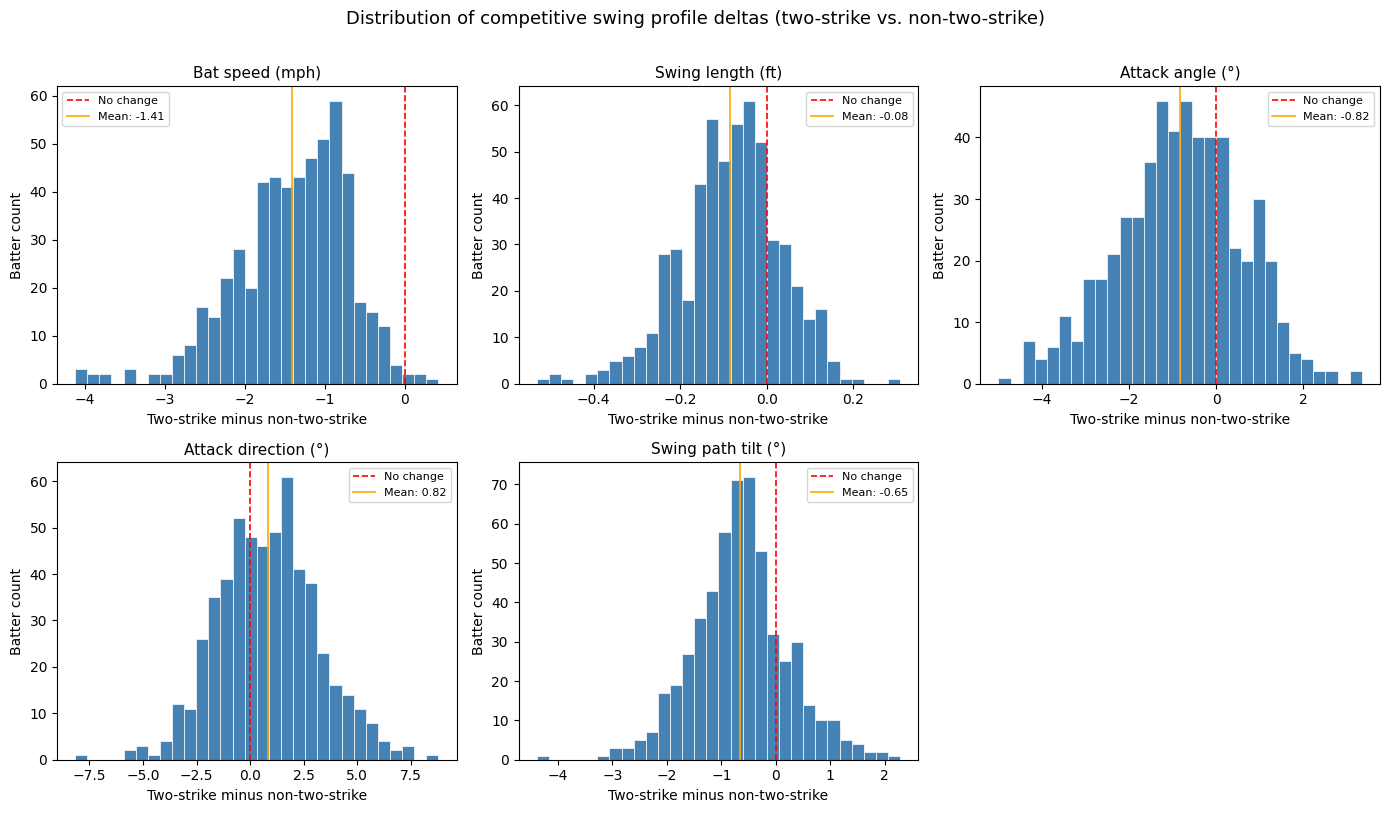

In [276]:
# columns to plot
delta_cols = [
    'delta_bat_speed', 'delta_swing_length', 'delta_attack_angle',
    'delta_attack_direction', 'delta_swing_path_tilt'
]

labels = {
    'delta_bat_speed':       'Bat speed (mph)',
    'delta_swing_length':    'Swing length (ft)',
    'delta_attack_angle':    'Attack angle (°)',
    'delta_attack_direction':'Attack direction (°)',
    'delta_swing_path_tilt': 'Swing path tilt (°)'
}

# histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(delta_cols):
    ax = axes[i]
    data = batter_profiles[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No change')
    ax.axvline(data.mean(), color='orange', linestyle='-', linewidth=1.2, 
               label=f'Mean: {data.mean():.2f}')
    ax.set_title(labels[col], fontsize=11)
    ax.set_xlabel('Two-strike minus non-two-strike')
    ax.set_ylabel('Batter count')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribution of competitive swing profile deltas (two-strike vs. non-two-strike)',
             fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig('delta_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

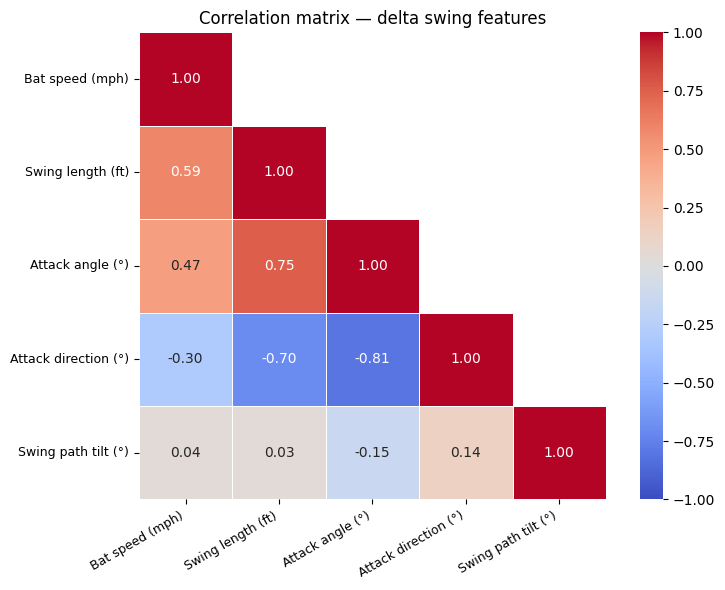

In [277]:
# correlation heat maps
corr = batter_profiles[delta_cols].corr()
readable_labels = [labels[c] for c in delta_cols]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    xticklabels=readable_labels,
    yticklabels=readable_labels,
    ax=ax
)
ax.set_title('Correlation matrix — delta swing features', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('delta_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [278]:
corr

,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt
delta_bat_speed,1.000000,0.588030,0.469124,-0.300309,0.037734
delta_swing_length,0.588030,1.000000,0.753004,-0.699449,0.031403
delta_attack_angle,0.469124,0.753004,1.000000,-0.810086,-0.148216
delta_attack_direction,-0.300309,-0.699449,-0.810086,1.000000,0.144983
delta_swing_path_tilt,0.037734,0.031403,-0.148216,0.144983,1.000000


In [279]:
## Examine Correlation's in two strike counts ?? ##

### 4. Clustering

In [280]:
# investigating PCA clustering...
scaler = StandardScaler()
scaled_features = scaler.fit_transform(batter_profiles[delta_cols])
pca = PCA(n_components=5)
pca.fit(scaled_features)
print(pca.explained_variance_ratio_) # 3 PCs = ~92% explained var

[0.57040651 0.21322932 0.13855217 0.04436039 0.03345162]


In [281]:
# PCA w/ 3 Components
pca = PCA(n_components=3)
pca_features = pca.fit_transform(scaled_features)

print("Explained variance by component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.1%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.1%}")

Explained variance by component:
  PC1: 57.0%
  PC2: 21.3%
  PC3: 13.9%
  Total: 92.2%


In [282]:
# investigate loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=delta_cols,
    columns=['PC1', 'PC2', 'PC3']
).round(3)
print("\nPCA Loadings:")
print(loadings)


PCA Loadings:
                          PC1    PC2    PC3
delta_bat_speed         0.390  0.327  0.786
delta_swing_length      0.536  0.159 -0.016
delta_attack_angle      0.545 -0.111 -0.179
delta_attack_direction -0.509  0.181  0.444
delta_swing_path_tilt  -0.066  0.907 -0.391


In [283]:
# stored as df
pca_df = pd.DataFrame(
    pca_features,
    index=batter_profiles.index,
    columns=['PC1', 'PC2', 'PC3']
)
pca_df.head(2)

,PC1,PC2,PC3
batter,,,
444482,0.078007,0.222545,-0.591207
453568,-0.935911,-0.424078,0.858709


In [284]:
batter_profiles.head()

,player_name,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg,bat_speed_other_avg,swing_length_other_avg,attack_angle_other_avg,attack_direction_other_avg,swing_path_tilt_other_avg,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt,stand
batter,,,,,,,,,,,,,,,,,
444482,david peralta,70.441611,7.080537,5.697427,-1.993372,30.859895,71.920805,7.235570,6.008812,-1.509173,31.038971,-1.479195,-0.155034,-0.311386,-0.484199,-0.179075,L
453568,charlie blackmon,66.539502,7.070819,8.513783,-3.731509,30.295976,67.937657,7.181381,10.253393,-6.941911,31.567735,-1.398155,-0.110562,-1.739609,3.210403,-1.271758,L
455117,martín maldonado,70.032903,7.487742,14.439228,-6.031537,30.515273,71.637857,7.650357,15.372984,-8.507114,31.399526,-1.604954,-0.162615,-0.933757,2.475577,-0.884253,R
456781,donovan solano,66.019499,6.956267,8.018851,-0.843517,34.704044,67.118913,6.991957,9.261834,-2.201103,34.507326,-1.099414,-0.035689,-1.242983,1.357585,0.196719,R
457705,andrew mccutchen,71.154874,7.674686,13.859085,-1.430344,33.022215,72.299312,7.589391,13.447179,0.276406,34.583457,-1.144438,0.085295,0.411906,-1.706750,-1.561242,R


In [285]:
batter_profiles.loc[701762]

player_name                     nick kurtz
bat_speed_2strike_avg            76.469919
swing_length_2strike_avg          7.714228
attack_angle_2strike_avg         13.810754
attack_direction_2strike_avg      2.049786
swing_path_tilt_2strike_avg      38.730447
bat_speed_other_avg              77.606004
swing_length_other_avg            7.701242
attack_angle_other_avg           14.461989
attack_direction_other_avg        1.575366
swing_path_tilt_other_avg        39.294875
delta_bat_speed                  -1.136085
delta_swing_length                0.012985
delta_attack_angle               -0.651235
delta_attack_direction             0.47442
delta_swing_path_tilt            -0.564427
stand                                    L
Name: 701762, dtype: object

#### 4.1 - K-Means

In [286]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_df)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_df, labels))
    print(f"k={k} | Inertia: {kmeans.inertia_:.1f} | Silhouette: {silhouette_score(pca_df, labels):.4f}")

k=2 | Inertia: 1572.6 | Silhouette: 0.3205
k=3 | Inertia: 1242.4 | Silhouette: 0.2799
k=4 | Inertia: 1044.7 | Silhouette: 0.2684
k=5 | Inertia: 931.0 | Silhouette: 0.2632
k=6 | Inertia: 849.5 | Silhouette: 0.2204
k=7 | Inertia: 775.9 | Silhouette: 0.2319
k=8 | Inertia: 712.9 | Silhouette: 0.2254
k=9 | Inertia: 678.3 | Silhouette: 0.2329
k=10 | Inertia: 631.2 | Silhouette: 0.2233


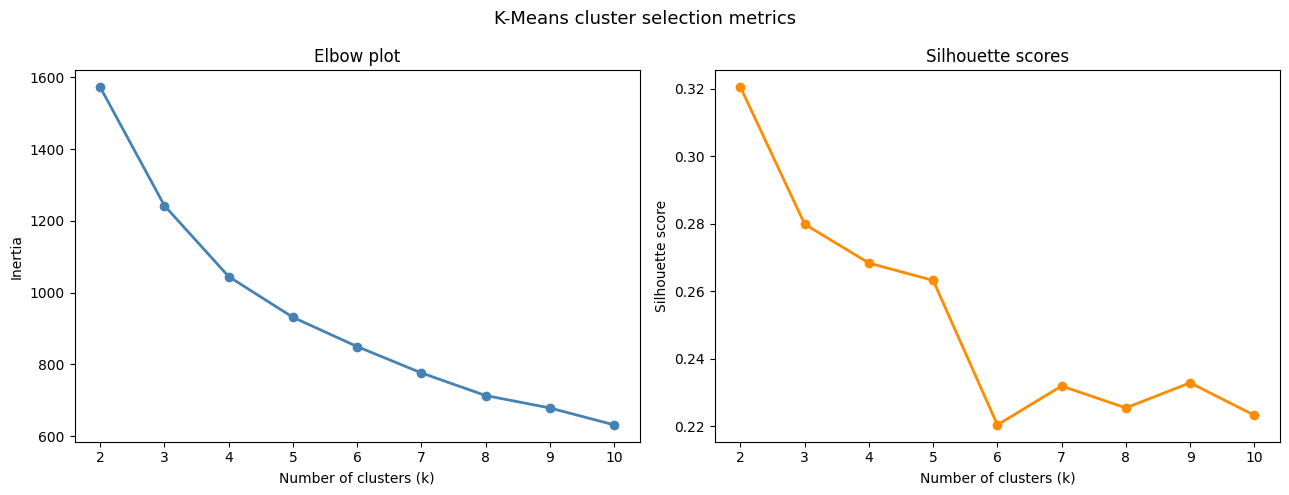

In [287]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# elbow plot
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=6)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow plot')
ax1.set_xticks(list(k_range))

# silhouette plot
ax2.plot(k_range, silhouette_scores, 'o-', color='darkorange', linewidth=2, markersize=6)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette scores')
ax2.set_xticks(list(k_range))

plt.suptitle('K-Means cluster selection metrics', fontsize=13)
plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [288]:
print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"{k:>4} {inertia:>12.1f} {sil:>12.4f}")


   k      Inertia   Silhouette
------------------------------
   2       1572.6       0.3205
   3       1242.4       0.2799
   4       1044.7       0.2684
   5        931.0       0.2632
   6        849.5       0.2204
   7        775.9       0.2319
   8        712.9       0.2254
   9        678.3       0.2329
  10        631.2       0.2233


In [289]:
# fitting k = 2 + k = 3
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
batter_profiles['cluster_k2'] = kmeans_2.fit_predict(pca_df)
batter_profiles['cluster_k3'] = kmeans_3.fit_predict(pca_df)

# check cluster sizes for both
print("k=2 distribution:")
print(batter_profiles['cluster_k2'].value_counts().sort_index())
print("\nk=3 distribution:")
print(batter_profiles['cluster_k3'].value_counts().sort_index())

k=2 distribution:
cluster_k2
0    258
1    293
Name: count, dtype: int64

k=3 distribution:
cluster_k3
0    282
1    160
2    109
Name: count, dtype: int64


In [290]:
# cluster centroids in original delta feature space

# k2 centroids
centroids_k2 = pd.DataFrame(
    scaler.inverse_transform(
        pca.inverse_transform(kmeans_2.cluster_centers_)
    ),
    columns=delta_cols
).round(3)
print("\nCluster centroids (k2) in original feature space:")
centroids_k2


Cluster centroids (k2) in original feature space:


,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt
0,-1.791,-0.172,-1.920,2.531,-0.551
1,-1.070,-0.007,0.146,-0.681,-0.739


In [291]:
# k3 centroids 
centroids_k3 = pd.DataFrame(
    scaler.inverse_transform(
        pca.inverse_transform(kmeans_3.cluster_centers_)
    ),
    columns=delta_cols
).round(3)
print("\nCluster centroids (k3) in original feature space:")
centroids_k3


Cluster centroids (k3) in original feature space:


,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt
0,-1.387,-0.093,-0.968,1.118,-0.626
1,-0.920,0.037,0.720,-1.623,-0.771
2,-2.178,-0.241,-2.704,3.651,-0.539


In [292]:
# Archetype naming based on k3 centroids
shortener_cluster = centroids_k3['delta_swing_length'].idxmin()
free_swinger_cluster = centroids_k3['delta_swing_length'].idxmax()
moderate_cluster = [i for i in range(3)
                    if i not in [shortener_cluster, free_swinger_cluster]][0]

cluster_names = {
    shortener_cluster: 'Committed Shortener',
    moderate_cluster:  'Moderate Adjustor',
    free_swinger_cluster: 'Free Swinger'
}

batter_profiles['archetype'] = batter_profiles['cluster_k3'].map(cluster_names)

print("\nArchetype distribution:")
print(batter_profiles['archetype'].value_counts())


Archetype distribution:
archetype
Moderate Adjustor      282
Free Swinger           160
Committed Shortener    109
Name: count, dtype: int64


In [296]:
# player check
notable_players = [
    'charlie blackmon', 'aaron judge', 'freddie freeman',
    'juan soto', 'yordan álvarez', 'luis arráez', 'nick kurtz', 'shohei ohtani'
]

print(batter_profiles[
    batter_profiles['player_name'].isin(notable_players)
][['player_name', 'archetype'] + delta_cols].to_string())

             player_name          archetype  delta_bat_speed  delta_swing_length  delta_attack_angle  delta_attack_direction  delta_swing_path_tilt
batter                                                                                                                                             
453568  charlie blackmon  Moderate Adjustor        -1.398155           -0.110562           -1.739609                3.210403              -1.271758
518692   freddie freeman  Moderate Adjustor        -1.686993           -0.083727           -1.115777                1.180171              -0.834165
592450       aaron judge  Moderate Adjustor        -1.108080           -0.040793           -1.432314                0.920771              -0.673996
650333       luis arráez  Moderate Adjustor        -1.208166           -0.001924           -0.386004                0.577897              -0.825853
660271     shohei ohtani  Moderate Adjustor        -2.365211           -0.056159           -1.173226            

In [295]:
# Sample notable players from each archetype
for archetype in ['Free Swinger', 'Moderate Adjustor', 'Committed Shortener']:
    print(f"\n{archetype}:")
    sample = (batter_profiles[batter_profiles['archetype'] == archetype]
              .nlargest(50, 'delta_bat_speed')  
              [['player_name', 'delta_bat_speed', 
                'delta_swing_length', 'delta_attack_angle']])
    print(sample.to_string())


Free Swinger:
                player_name  delta_bat_speed  delta_swing_length  delta_attack_angle
batter                                                                              
701350        roman anthony         0.425034            0.123775            1.451127
608385         jesse winker         0.259623            0.101714            1.067119
664913           seth brown         0.241275            0.072392            1.050822
695681      christian moore         0.090845           -0.026204            0.472761
696030      alejandro osuna        -0.000349           -0.027853           -0.066932
686668        brenton doyle        -0.040278           -0.029948            0.232059
669016        brandon marsh        -0.079289            0.058284            0.270627
686676            korey lee        -0.127113            0.005211            0.614680
672820           lenyn sosa        -0.136566            0.113117            0.631404
641584          jake fraley        -0.188821      

In [163]:
# Most extreme shorteners
print("Most committed shorteners:")
print(batter_profiles[batter_profiles['archetype'] == 'Committed Shortener']
      .nsmallest(5, 'delta_swing_length')
      [['player_name', 'archetype'] + delta_cols].to_string())

# Most extreme free swingers  
print("\nMost extreme free swingers:")
print(batter_profiles[batter_profiles['archetype'] == 'Free Swinger']
      .nlargest(5, 'delta_swing_length')
      [['player_name', 'archetype'] + delta_cols].to_string())

Most committed shorteners:
            player_name            archetype  delta_bat_speed  delta_swing_length  delta_attack_angle  delta_attack_direction  delta_swing_path_tilt
batter                                                                                                                                              
691019        kyle teel  Committed Shortener        -3.743740           -0.531464           -3.793152                2.116916               0.221597
571466  tucker barnhart  Committed Shortener        -2.480654           -0.486013           -4.397735                7.352953               0.098587
660766       juan yepez  Committed Shortener        -2.792074           -0.484922           -2.776278                3.804607              -0.396519
668723      ryan vilade  Committed Shortener        -1.356707           -0.461901           -4.198470                6.283855              -1.524162
500743     miguel rojas  Committed Shortener        -2.063845           -0.4176

In [297]:
# stanton check
batter_profiles[batter_profiles['player_name'] == 'giancarlo stanton']

,player_name,bat_speed_2strike_avg,swing_length_2strike_avg,attack_angle_2strike_avg,attack_direction_2strike_avg,swing_path_tilt_2strike_avg,bat_speed_other_avg,swing_length_other_avg,attack_angle_other_avg,attack_direction_other_avg,swing_path_tilt_other_avg,delta_bat_speed,delta_swing_length,delta_attack_angle,delta_attack_direction,delta_swing_path_tilt,stand,cluster_k2,cluster_k3,archetype
batter,,,,,,,,,,,,,,,,,,,,
519317,giancarlo stanton,80.474449,8.621366,9.775223,-3.868244,26.014041,81.335461,8.666383,9.10656,-2.871845,27.31129,-0.861012,-0.045017,0.668662,-0.996399,-1.297249,R,1,1,Free Swinger


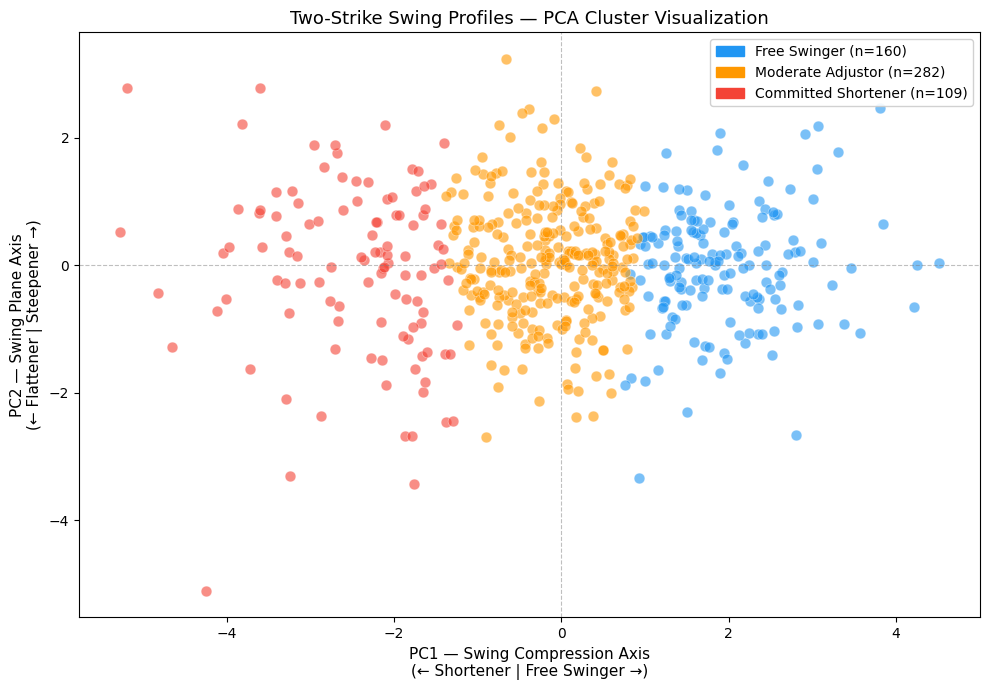

In [298]:
# Color palette — consistent across all plots
archetype_colors = {
    'Free Swinger':       '#2196F3',  # blue
    'Moderate Adjustor':  '#FF9800',  # orange
    'Committed Shortener':'#F44336'   # red
}

# Add PCA coords and archetype to one working dataframe
plot_df = pca_df.copy()
plot_df['archetype'] = batter_profiles['archetype'].values


# PLOT 1 — PCA SCATTER (PC1 vs PC2)

fig, ax = plt.subplots(figsize=(10, 7))

for archetype, color in archetype_colors.items():
    subset = plot_df[plot_df['archetype'] == archetype]
    ax.scatter(
        subset['PC1'], subset['PC2'],
        c=color, label=archetype,
        alpha=0.6, edgecolors='white',
        linewidths=0.4, s=60
    )

# Reference lines
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Axis labels with interpretation
ax.set_xlabel('PC1 — Swing Compression Axis\n(← Shortener | Free Swinger →)',
              fontsize=11)
ax.set_ylabel('PC2 — Swing Plane Axis\n(← Flattener | Steepener →)',
              fontsize=11)
ax.set_title('Two-Strike Swing Profiles — PCA Cluster Visualization',
             fontsize=13)

legend_patches = [
    mpatches.Patch(color=color, label=f"{archetype} (n={len(plot_df[plot_df['archetype']==archetype])})")
    for archetype, color in archetype_colors.items()
]
ax.legend(handles=legend_patches, fontsize=10, framealpha=0.9)
plt.tight_layout()
#plt.savefig('pca_cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

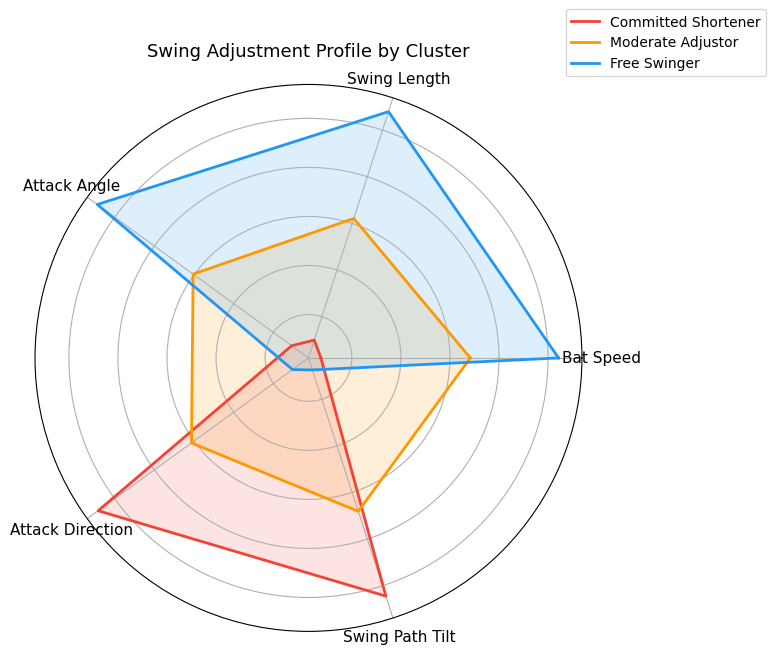

In [299]:
## spider chart by profile
# features / display labels
radar_features = delta_cols
radar_labels = [
    'Bat Speed', 'Swing Length',
    'Attack Angle', 'Attack Direction', 'Swing Path Tilt'
]

# normalize centroids to [-1, 1]
centroid_values = centroids_k3[radar_features].values
centroid_norm = (centroid_values - centroid_values.mean(axis=0)) / centroid_values.std(axis=0)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (cluster_id, archetype) in enumerate(cluster_names.items()):
    values = centroid_norm[cluster_id].tolist()
    values += values[:1]  
    color = archetype_colors[archetype]
    ax.plot(angles, values, color=color, linewidth=2, label=archetype)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_yticklabels([])  
ax.set_title('Swing Adjustment Profile by Cluster',
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('radar_archetypes.png', dpi=150, bbox_inches='tight')
plt.show()

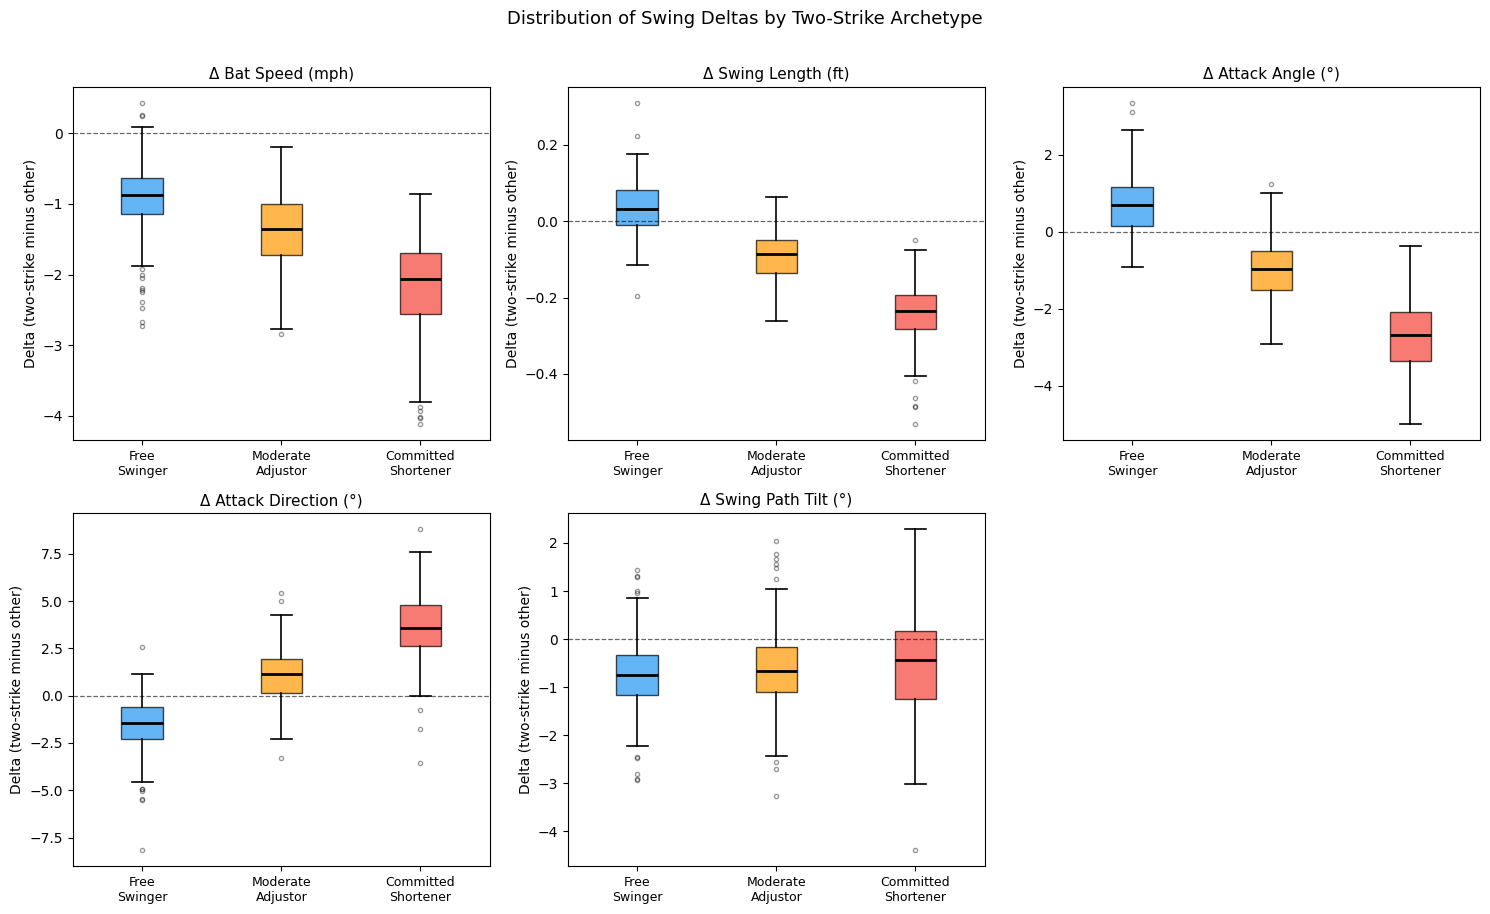

In [300]:
## box plots by archetype

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

box_labels = {
    'delta_bat_speed':        'Δ Bat Speed (mph)',
    'delta_swing_length':     'Δ Swing Length (ft)',
    'delta_attack_angle':     'Δ Attack Angle (°)',
    'delta_attack_direction': 'Δ Attack Direction (°)',
    'delta_swing_path_tilt':  'Δ Swing Path Tilt (°)'
}

archetype_order = ['Free Swinger', 'Moderate Adjustor', 'Committed Shortener']
colors = [archetype_colors[a] for a in archetype_order]

for i, (col, label) in enumerate(box_labels.items()):
    ax = axes[i]
    data_by_archetype = [
        batter_profiles[batter_profiles['archetype'] == a][col].dropna()
        for a in archetype_order
    ]
    bp = ax.boxplot(
        data_by_archetype,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.9, alpha=0.6)
    ax.set_title(label, fontsize=11)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(
        [a.replace(' ', '\n') for a in archetype_order],
        fontsize=9
    )
    ax.set_ylabel('Delta (two-strike minus other)')

axes[-1].set_visible(False)
fig.suptitle('Distribution of Swing Deltas by Two-Strike Archetype',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boxplots_archetypes.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Predictive Modeling

#### 5.1 - Data Cleaning

In [301]:
# balls in play w/ two strike counts
df_contact = df_swings_comp[
    (df_swings_comp['strikes'] == 2) &
    (df_swings_competitive['description'] == 'hit_into_play') &
    (df_swings_competitive['estimated_woba_using_speedangle'].notna())
].copy()

print(f"Two-strike contact events: {len(df_contact):,}")
print(f"Unique batters: {df_contact['batter'].nunique()}")
print(f"\nxwOBA distribution:")
print(df_contact['estimated_woba_using_speedangle'].describe().round(3))

Two-strike contact events: 71,079
Unique batters: 551

xwOBA distribution:
count    71079.000
mean         0.359
std          0.362
min          0.000
25%          0.072
50%          0.244
75%          0.547
max          2.018
Name: estimated_woba_using_speedangle, dtype: float64


In [302]:
# add arch from batter_profiles
df_contact = df_contact.join(
    batter_profiles[['archetype', 'cluster_k3']],
    on='batter',
    how='inner'
)

print(f"\nContact events by archetype:")
print(df_contact['archetype'].value_counts())


Contact events by archetype:
archetype
Moderate Adjustor      37591
Free Swinger           18879
Committed Shortener    14609
Name: count, dtype: int64


In [303]:
## Add batter name
# unique batter IDs 
contact_batter_ids = df_contact['batter'].unique().tolist()

# name lookup
contact_batter_names = playerid_reverse_lookup(contact_batter_ids, key_type='mlbam')

# name mapping
contact_batter_names = (contact_batter_names[['key_mlbam', 'name_first', 'name_last']]
                        .set_index('key_mlbam'))
contact_batter_names['batter_name'] = (contact_batter_names['name_first'] + ' ' + 
                                        contact_batter_names['name_last'])

# join to df_contact
df_contact = df_contact.join(
    contact_batter_names[['batter_name']], 
    on='batter'
)

# verify
print(f"Names matched: {df_contact['batter_name'].notna().sum():,} of {len(df_contact):,}")
print(df_contact[['batter', 'batter_name', 'archetype']].head(10))

Names matched: 71,079 of 71,079
     batter        batter_name            archetype
13   545341     randal grichuk    Moderate Adjustor
28   682998     corbin carroll         Free Swinger
39   663604  brandon lockridge         Free Swinger
47   642180         tyler wade         Free Swinger
65   664983      jake mccarthy    Moderate Adjustor
76   553869         elías díaz  Committed Shortener
97   682998     corbin carroll         Free Swinger
119  630105   jake cronenworth    Moderate Adjustor
151  553869         elías díaz  Committed Shortener
158  666971    lourdes gurriel    Moderate Adjustor


In [304]:
# verify high xwOBA events
df_contact[df_contact['estimated_woba_using_speedangle'] > 2.0][['batter_name', 'estimated_woba_using_speedangle', 
        'launch_speed', 'launch_angle', 'events']].nlargest(10, 'estimated_woba_using_speedangle')

,batter_name,estimated_woba_using_speedangle,launch_speed,launch_angle,events
939223,kyle schwarber,2.018000,115.4,28.0,home_run
1430277,aaron judge,2.016600,113.1,28.0,home_run
116066,griffin conine,2.012600,112.5,27.0,home_run
501923,matt olson,2.012600,113.4,27.0,home_run
472334,juan soto,2.010667,113.1,31.0,home_run
846248,joc pederson,2.005750,113.7,26.0,home_run
273258,bryce harper,2.004250,113.8,27.0,home_run
149699,heliot ramos,2.003667,111.8,26.0,home_run
335377,riley greene,2.003667,111.8,26.0,home_run
1109490,michael busch,2.003286,111.9,26.0,home_run


In [305]:
# adj columns for df_contact 

# rename to xwoba
df_contact = df_contact.rename(
    columns={'estimated_woba_using_speedangle': 'xwoba'}
)

# ideal column order
col_order = [
    # id
    'game_date', 'game_year',
    'player_name', 'pitcher',
    'batter_name', 'batter',
    # game context
    'inning', 'inning_topbot', 'outs_when_up',
    'at_bat_number', 'pitch_number',
    'home_team', 'away_team',
    # batter/pitcher attributes
    'stand', 'p_throws', 'arm_angle',
    # Count
    'balls', 'strikes',
    # pitch features
    'pitch_type', 'release_speed', 'effective_speed',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z',
    # swing / bat tracking
    'bat_speed', 'swing_length', 'attack_angle',
    'attack_direction', 'swing_path_tilt',
    # contact quality & outcomes
    'launch_speed', 'launch_angle',
    'xwoba', 'woba_value',
    'events', 'description', 'des',
    # other
    'p10_bat_speed', 'archetype', 'cluster_k3'
]

df_contact = df_contact[col_order]

# Verify
print(df_contact.columns.tolist())
print(df_contact.shape)

['game_date', 'game_year', 'player_name', 'pitcher', 'batter_name', 'batter', 'inning', 'inning_topbot', 'outs_when_up', 'at_bat_number', 'pitch_number', 'home_team', 'away_team', 'stand', 'p_throws', 'arm_angle', 'balls', 'strikes', 'pitch_type', 'release_speed', 'effective_speed', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'bat_speed', 'swing_length', 'attack_angle', 'attack_direction', 'swing_path_tilt', 'launch_speed', 'launch_angle', 'xwoba', 'woba_value', 'events', 'description', 'des', 'p10_bat_speed', 'archetype', 'cluster_k3']
(71079, 40)


In [306]:
# swing features
swing_features = [
    'bat_speed', 'swing_length', 'attack_angle',
    'attack_direction', 'swing_path_tilt'
]

# pitch control vars
pitch_features = [
    'release_speed', 'effective_speed',
    'pfx_x', 'pfx_z',
    'plate_x', 'plate_z'
]

# combine
feature_cols = swing_features + pitch_features

# response
target_col = 'xwoba'

# Check for nulls in features
print("\nNull counts in feature columns:")
print(df_contact[feature_cols].isnull().sum())


Null counts in feature columns:
bat_speed            0
swing_length         0
attack_angle         0
attack_direction     0
swing_path_tilt      0
release_speed        0
effective_speed     25
pfx_x                6
pfx_z                0
plate_x              0
plate_z              0
dtype: int64


In [307]:
# dropping effetive_speed column and null pfx_x
print('Before drops: ', df_contact.shape)
df_contact = df_contact.drop(columns=['effective_speed'])
df_contact = df_contact.dropna(subset=['pfx_x'])
print('After drops: ', df_contact.shape)

Before drops:  (71079, 40)
After drops:  (71073, 39)


In [308]:
feature_cols.remove('effective_speed')
feature_cols

['bat_speed',
 'swing_length',
 'attack_angle',
 'attack_direction',
 'swing_path_tilt',
 'release_speed',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z']

#### 5.2 - Modeling

In [309]:
# training data /response 
X = df_contact[feature_cols]
y = df_contact[target_col]
groups = df_contact['batter']  # player-split key

# 5-fold cv split by player
gkf = GroupKFold(n_splits=5)

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"Total samples: {len(X):,}")
print(f"Unique batters: {groups.nunique()}")

Features: ['bat_speed', 'swing_length', 'attack_angle', 'attack_direction', 'swing_path_tilt', 'release_speed', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z']
Target: xwoba
Total samples: 71,073
Unique batters: 551


In [310]:
# store results
results = {
    'Linear Regression': {'rmse': [], 'mae': []},
    'Random Forest':     {'rmse': [], 'mae': []},
    'XGBoost':           {'rmse': [], 'mae': []}
}

# model definition   
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"Fold {fold+1} | Train: {len(X_train):,} | Test: {len(X_test):,}")

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)

Fold 1 | Train: 56,860 | Test: 14,213
Fold 2 | Train: 56,860 | Test: 14,213
Fold 3 | Train: 56,851 | Test: 14,222
Fold 4 | Train: 56,860 | Test: 14,213
Fold 5 | Train: 56,861 | Test: 14,212


In [179]:
# CV Results 
print(f"\n{'Model':<20} {'RMSE Mean':>10} {'RMSE Std':>10} {'MAE Mean':>10} {'MAE Std':>10}")
print("-" * 62)
for name, metrics in results.items():
    rmse_mean = np.mean(metrics['rmse'])
    rmse_std  = np.std(metrics['rmse'])
    mae_mean  = np.mean(metrics['mae'])
    mae_std   = np.std(metrics['mae'])
    print(f"{name:<20} {rmse_mean:>10.4f} {rmse_std:>10.4f} {mae_mean:>10.4f} {mae_std:>10.4f}")


Model                 RMSE Mean   RMSE Std   MAE Mean    MAE Std
--------------------------------------------------------------
Linear Regression        0.3556     0.0049     0.2778     0.0035
Random Forest            0.3522     0.0048     0.2747     0.0031
XGBoost                  0.3512     0.0049     0.2725     0.0034


In [180]:
# full model fit
best_model_name = 'XGBoost'  # update after reviewing CV results

final_model = models[best_model_name]
final_model.fit(X, y)
df_contact['predicted_xwoba'] = final_model.predict(X)

print(f"\nFinal model: {best_model_name}")
print(f"Predictions added to df_contact")
print(df_contact['predicted_xwoba'].describe().round(3))


Final model: XGBoost
Predictions added to df_contact
count    71073.000
mean         0.359
std          0.099
min          0.031
25%          0.291
50%          0.348
75%          0.413
max          1.314
Name: predicted_xwoba, dtype: float64



Feature importances:
         feature  importance
       bat_speed    0.229913
         plate_x    0.132617
attack_direction    0.106704
    attack_angle    0.106272
         plate_z    0.087789
 swing_path_tilt    0.083264
           pfx_z    0.069734
    swing_length    0.062350
           pfx_x    0.062232
   release_speed    0.059125


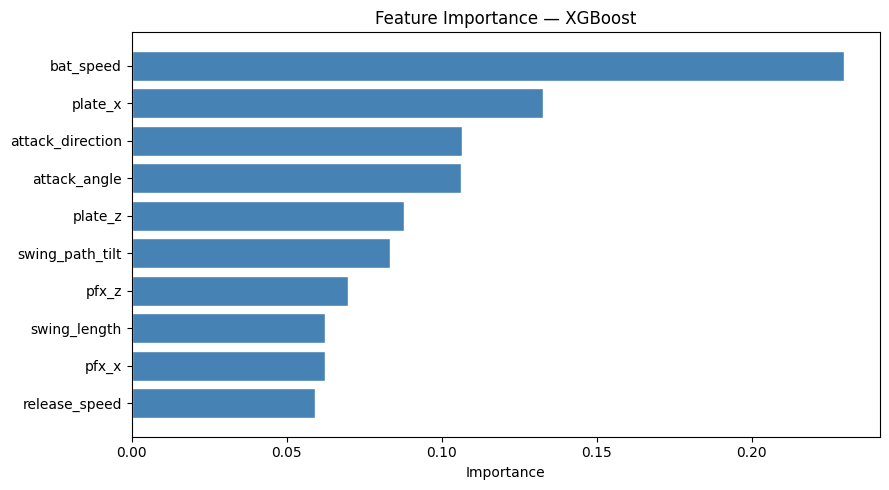

In [311]:
# feature importance 
if best_model_name in ['XGBoost', 'Random Forest']:
    importances = pd.DataFrame({
        'feature': feature_cols,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nFeature importances:")
    print(importances.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(importances['feature'][::-1],
            importances['importance'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance — {best_model_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 5.3 ANOVA 

In [184]:
# Aggregate predicted xwOBA to batter level
# Using batter-level means avoids pseudo-replication
# (pitch-level observations aren't independent within a batter)
batter_xwoba = (df_contact
                .groupby(['batter', 'batter_name', 'archetype'])['predicted_xwoba']
                .mean()
                .reset_index()
                .rename(columns={'predicted_xwoba': 'mean_predicted_xwoba'}))

print(f"Batters in ANOVA: {len(batter_xwoba)}")
print(f"\nArchetype distribution:")
print(batter_xwoba['archetype'].value_counts())
print(f"\nMean predicted xwOBA by archetype:")
print(batter_xwoba.groupby('archetype')['mean_predicted_xwoba']
      .agg(['mean', 'std', 'count']).round(4))

Batters in ANOVA: 551

Archetype distribution:
archetype
Moderate Adjustor      282
Free Swinger           160
Committed Shortener    109
Name: count, dtype: int64

Mean predicted xwOBA by archetype:
                       mean     std  count
archetype                                 
Committed Shortener  0.3458  0.0367    109
Free Swinger         0.3655  0.0365    160
Moderate Adjustor    0.3566  0.0380    282


In [185]:
# Separate groups
free_swingers = batter_xwoba[batter_xwoba['archetype'] == 'Free Swinger']['mean_predicted_xwoba']
moderate = batter_xwoba[batter_xwoba['archetype'] == 'Moderate Adjustor']['mean_predicted_xwoba']
shorteners = batter_xwoba[batter_xwoba['archetype'] == 'Committed Shortener']['mean_predicted_xwoba']

# Normality test — Shapiro-Wilk
print("Normality tests (Shapiro-Wilk):")
for name, group in [('Free Swinger', free_swingers), 
                     ('Moderate Adjustor', moderate),
                     ('Committed Shortener', shorteners)]:
    stat, p = shapiro(group)
    result = 'NORMAL ✓' if p > 0.05 else 'NON-NORMAL ✗'
    print(f"  {name:<25} W={stat:.4f}  p={p:.4f}  {result}")

# Homoscedasticity test — Levene's
stat, p = levene(free_swingers, moderate, shorteners)
result = 'EQUAL VARIANCE ✓' if p > 0.05 else 'UNEQUAL VARIANCE ✗'
print(f"\nLevene's test for equal variance:")
print(f"  W={stat:.4f}  p={p:.4f}  {result}")

Normality tests (Shapiro-Wilk):
  Free Swinger              W=0.9932  p=0.6623  NORMAL ✓
  Moderate Adjustor         W=0.9841  p=0.0032  NON-NORMAL ✗
  Committed Shortener       W=0.9601  p=0.0024  NON-NORMAL ✗

Levene's test for equal variance:
  W=0.1028  p=0.9024  EQUAL VARIANCE ✓


In [191]:
print("\n--- ANOVA RESULTS ---")

# Check assumption results and run appropriate test

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(free_swingers, moderate, shorteners)
print(f"\nOne-way ANOVA:")
print(f"  F={f_stat:.4f}  p={p_anova:.4f}")
print(f"  {'SIGNIFICANT ✓' if p_anova < 0.05 else 'NOT SIGNIFICANT ✗'} (α=0.05)")

# Welch's ANOVA — robust to unequal variances
from pingouin import welch_anova
welch_result = welch_anova(
    data=batter_xwoba,
    dv='mean_predicted_xwoba',
    between='archetype'
)
print(f"\nWelch's ANOVA:")
print(welch_result[['Source', 'ddof1', 'ddof2', 'F', 'p_unc']].to_string(index=False))

# Kruskal-Wallis — non-parametric fallback
h_stat, p_kruskal = kruskal(free_swingers, moderate, shorteners)
print(f"\nKruskal-Wallis test:")
print(f"  H={h_stat:.4f}  p={p_kruskal:.4f}")
print(f"  {'SIGNIFICANT ✓' if p_kruskal < 0.05 else 'NOT SIGNIFICANT ✗'} (α=0.05)")


--- ANOVA RESULTS ---

One-way ANOVA:
  F=9.0706  p=0.0001
  SIGNIFICANT ✓ (α=0.05)

Welch's ANOVA:
   Source  ddof1      ddof2        F    p_unc
archetype      2 271.065454 9.391012 0.000114

Kruskal-Wallis test:
  H=19.2187  p=0.0001
  SIGNIFICANT ✓ (α=0.05)


In [196]:
from pingouin import pairwise_tukey, pairwise_gameshowell

print("\n--- POST-HOC TESTS ---")

# Tukey HSD — assumes equal variance
print("\nTukey HSD (assumes equal variance):")
tukey = pairwise_tukey(
    data=batter_xwoba,
    dv='mean_predicted_xwoba',
    between='archetype'
)
print(tukey[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_tukey']].to_string(index=False))

# Games-Howell — robust to unequal variance
print("\nGames-Howell (robust to unequal variance):")
gh = pairwise_gameshowell(
    data=batter_xwoba,
    dv='mean_predicted_xwoba',
    between='archetype'
)
print(gh[['A', 'B', 'mean_A', 'mean_B', 'diff', 'pval']].to_string(index=False))


--- POST-HOC TESTS ---

Tukey HSD (assumes equal variance):
                  A                 B   mean_A   mean_B      diff  p_tukey
Committed Shortener      Free Swinger 0.345806 0.365510 -0.019704 0.000075
Committed Shortener Moderate Adjustor 0.345806 0.356566 -0.010760 0.029291
       Free Swinger Moderate Adjustor 0.365510 0.356566  0.008944 0.041861

Games-Howell (robust to unequal variance):
                  A                 B   mean_A   mean_B      diff     pval
Committed Shortener      Free Swinger 0.345806 0.365510 -0.019704 0.000067
Committed Shortener Moderate Adjustor 0.345806 0.356566 -0.010760 0.029100
       Free Swinger Moderate Adjustor 0.365510 0.356566  0.008944 0.040495


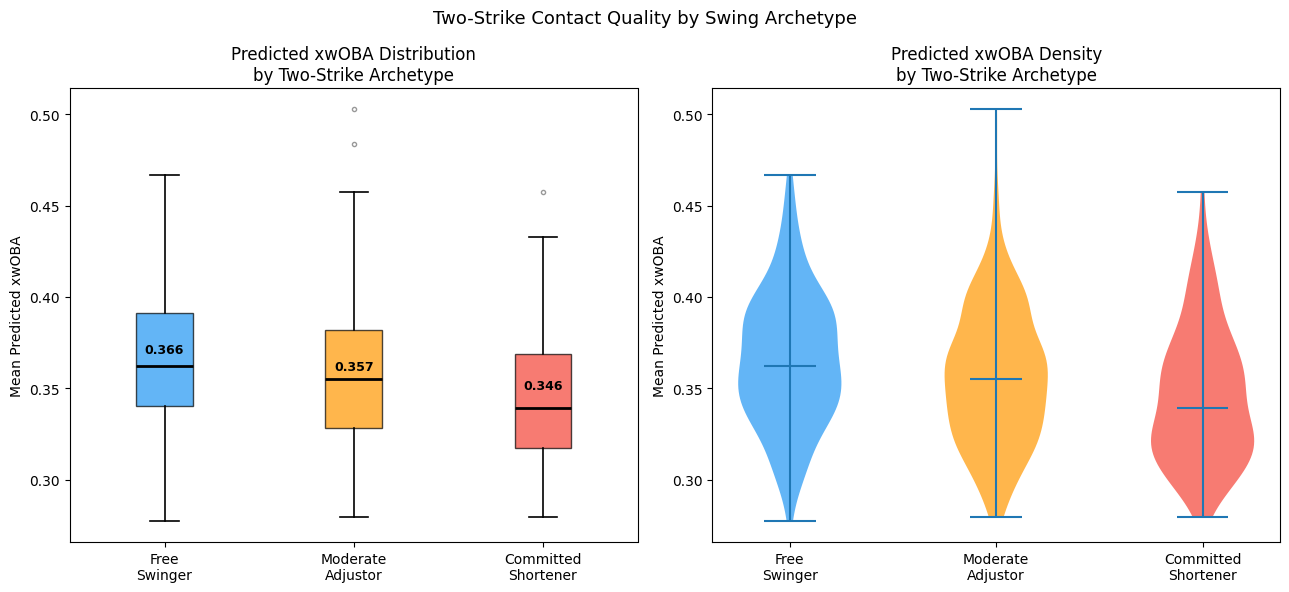

In [197]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

archetype_order = ['Free Swinger', 'Moderate Adjustor', 'Committed Shortener']
colors = ['#2196F3', '#FF9800', '#F44336']

# Box plot
bp = ax1.boxplot(
    [batter_xwoba[batter_xwoba['archetype'] == a]['mean_predicted_xwoba']
     for a in archetype_order],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels([a.replace(' ', '\n') for a in archetype_order], fontsize=10)
ax1.set_ylabel('Mean Predicted xwOBA')
ax1.set_title('Predicted xwOBA Distribution\nby Two-Strike Archetype')

# Add mean labels
for i, archetype in enumerate(archetype_order):
    mean_val = batter_xwoba[batter_xwoba['archetype'] == archetype]['mean_predicted_xwoba'].mean()
    ax1.text(i+1, mean_val + 0.002, f'{mean_val:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Violin plot
parts = ax2.violinplot(
    [batter_xwoba[batter_xwoba['archetype'] == a]['mean_predicted_xwoba']
     for a in archetype_order],
    positions=[1, 2, 3],
    showmedians=True,
    showmeans=False
)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels([a.replace(' ', '\n') for a in archetype_order], fontsize=10)
ax2.set_ylabel('Mean Predicted xwOBA')
ax2.set_title('Predicted xwOBA Density\nby Two-Strike Archetype')

plt.suptitle('Two-Strike Contact Quality by Swing Archetype', fontsize=13)
plt.tight_layout()
plt.savefig('anova_xwoba_distributions.png', dpi=150, bbox_inches='tight')
plt.show()